<div style="background-color: #f3e5f5; padding: 25px; border-radius: 15px; border: 2px solid #7b1fa2; box-shadow: 2px 2px 8px rgba(0,0,0,0.1); text-align: center; direction: rtl; font-family: 'Vazir', Tahoma, sans-serif;">
<div style="color: #4a148c; font-size: 2em; font-weight: bold; margin-bottom: 8px;">کتاب درک شهودی یادگیری ماشین</div>
<hr style="border: none; border-top: 2px solid #7b1fa2; width: 50%; margin: 12px auto;">
<h2 style="color: #4a148c; margin: 0; font-size: 1.5em; border-bottom: none;">فصل پانزدهم: یادگیری تجمیعی: ترکیب مدل‌ها برای بهبود مدل‌ها</h2>
</div>

<div dir="rtl" align="right">

# مثال تکمیلی رگرسیون با درخت تصمیم

در این مثال، درخت تصمیم رگرسیونی روی همان ده ردیف حقوق برازش می‌شود. مدل مقدار حقوق را برای سطح ۶٫۵ تخمین می‌زند و شکل تابع پیش‌بینی‌شده در کنار داده‌های مشاهده‌شده نمایش داده می‌شود.

</div>

<div dir="rtl" align="right">

## آماده‌سازی
سلول‌ها را از بالا به پایین اجرا کنید. فایل `Position_Salaries.csv` باید در پوشهٔ `data` کنار پوشهٔ نوت‌بوک‌ها قرار داشته باشد.

</div>

In [1]:
# آماده‌سازی
%matplotlib inline
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# پوشهٔ داده کنار پوشهٔ نوت‌بوک‌ها قرار دارد.
DATA = Path("../data")
if not DATA.is_dir():
    DATA = Path("data")
if not DATA.is_dir():
    raise FileNotFoundError("پوشهٔ data پیدا نشد؛ فایل‌های داده را طبق توضیح کنار نوت‌بوک قرار دهید.")
plt.rcParams.update({"figure.figsize": (8, 4), "font.size": 11})

<div dir="rtl" align="right">

## ۱. خواندن دادهٔ حقوق

`Level` سطح شغلی است، نه تعداد سال‌های سابقه. داده فقط ده ردیف دارد؛ بنابراین این مثال برای نمایش شکل برازش است و آزمون مستقلی برای سنجش تعمیم مدل ندارد.

</div>

In [2]:
# خواندن دادهٔ حقوق
data = pd.read_csv(DATA / "Position_Salaries.csv")
X = data[["Level"]].to_numpy()
y = data["Salary"].to_numpy()
grid = np.arange(float(X.min()), float(X.max()) + 0.01, 0.01).reshape(-1, 1)
display(data)

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000
5,Region Manager,6,150000
6,Partner,7,200000
7,Senior Partner,8,300000
8,C-level,9,500000
9,CEO,10,1000000


<div dir="rtl" align="right">

## ۲. آموزش درخت تصمیم و نمایش برآورد

درخت رگرسیون مقدار ثابتی را در هر ناحیهٔ برگ پیش‌بینی می‌کند؛ به همین دلیل خط برازش پله‌ای است. عمق درخت در این مثال محدود نشده و مدل با هدف نمایش برازش روی دادهٔ آموزشی آموزش داده می‌شود، نه به‌عنوان مدل بهینه برای پیش‌بینی دادهٔ جدید.

</div>

برآورد حقوق برای Level=6.5: 150,000.00
عمق درخت: 6 | تعداد برگ‌ها: 10


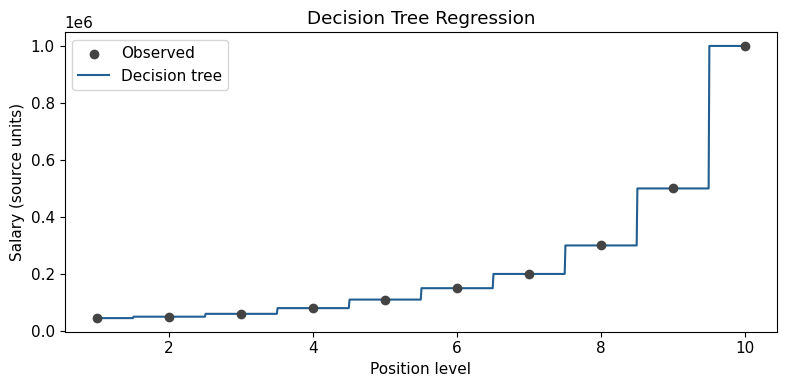

In [3]:
# آموزش درخت تصمیم رگرسیونی
from sklearn.tree import DecisionTreeRegressor, plot_tree

model = DecisionTreeRegressor(random_state=0)
model.fit(X, y)
estimate_65 = model.predict([[6.5]])[0]
print(f"برآورد حقوق برای Level=6.5: {estimate_65:,.2f}")
print("عمق درخت:", model.get_depth(), "| تعداد برگ‌ها:", model.get_n_leaves())

plt.scatter(X[:, 0], y, color="#444444", label="Observed", zorder=3)
plt.plot(grid[:, 0], model.predict(grid), color="#215e91", label="Decision tree")
plt.xlabel("Position level")
plt.ylabel("Salary (source units)")
plt.title("Decision Tree Regression")
plt.legend()
plt.tight_layout()
plt.show()

<div dir="rtl" align="right">

## ۳. نمایش ساختار درخت

برای خوانایی، نمودار ساختار تا عمق دو نمایش داده می‌شود؛ خود مدل ممکن است عمق بیشتری داشته باشد. هر برگ، میانگین هدف نمونه‌های آموزشی واقع در آن برگ را پیش‌بینی می‌کند.

</div>

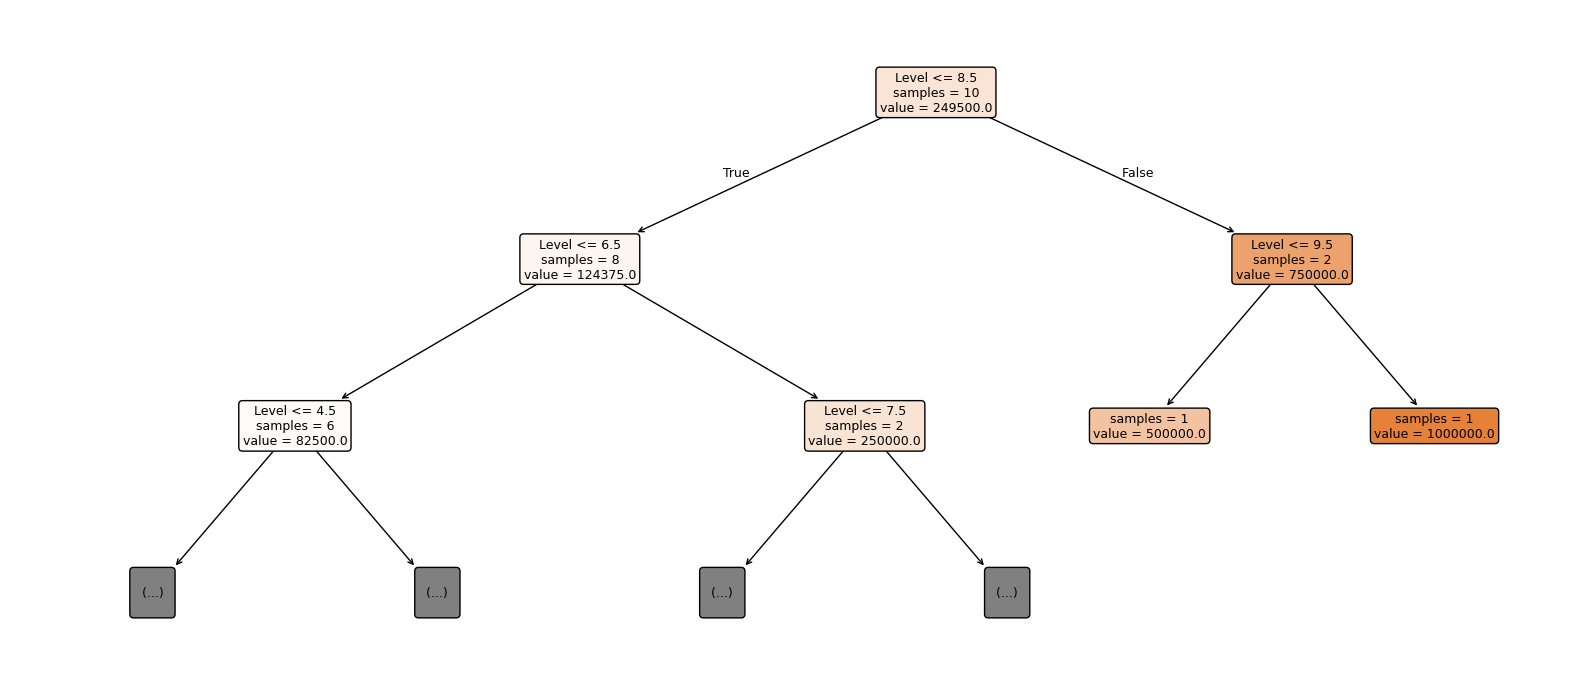

In [4]:
# نمایش بخش بالایی درخت
plt.figure(figsize=(16, 7))
plot_tree(model, feature_names=["Level"], filled=True, rounded=True,
          max_depth=2, fontsize=9, impurity=False)
plt.tight_layout()
plt.show()

<div dir="rtl" align="right">

## نکتهٔ پایانی

درخت تصمیم برخلاف جنگل تصادفی، یک درخت واحد است و از میانگین‌گیری چندین درخت استفاده نمی‌کند. درخت عمیق می‌تواند دادهٔ آموزشی کوچک را به‌خوبی برازش کند، اما این موضوع به‌تنهایی کیفیت پیش‌بینی روی نمونه‌های تازه را تضمین نمی‌کند. برای انتخاب عمق مناسب، به دادهٔ بیشتر و ارزیابی مستقل نیاز است.

</div>

<div dir="rtl" align="right">

## مأخذ مثال

مراجع فنی: [scikit-learn — Decision Trees](https://scikit-learn.org/stable/modules/tree.html)، [pandas](https://pandas.pydata.org/docs/).

</div>